# FGV QUANT - Econometria (cross-section)

A **econometria** é uma disciplina que combina conceitos da economia, estatística e matemática para entender e quantificar as relações entre variáveis. Nesta aula, começaremos explorando a econometria de cross-section, que se concentra na análise de dados em um **único ponto no tempo** para diferentes indivíduos (ou seja, várias variáveis em uma unidade fixa de tempo).

Comparado a dados de séries temporais (que observam as mesmas unidades ao longo do tempo) ou dados de painel (que combinam informações de cross-section e séries temporais), o **cross-section** fornece insights valiosos sobre a variação entre as unidades em um momento específico. Nossa jornada começará definindo variáveis dependentes e independentes, que são essenciais na construção de modelos econométricos.

Resumidamente, cross-section obseva 1 unidade de tempo e N variáveis, enquanto os dados de séries temporais (time-series) observa N unidade de tempo e 1 variável.

## 1 - Modelos univariados

Modelos univariados são modelos em que analisamos uma variável dependente (Y) e tentamos explicar seu comportamento.
Por exemplo:
$$ Y_i = \beta_0 + \beta_1X_i + u_i $$
Y = variável dependente → aquilo que queremos explicar
X = variável explicativa → aquilo que usamos para explicar Y
\(\beta_0\) = intercepto
\(\beta_1\) = efeito de X sobre Y
\(u_i\) = erro

## 1.1 - O que é econometria

Econometria é a área que combina Economia + Estatística + Matemática para usar dados e testar/analisar relações econômicas.

Ela permite:

-medir relações entre variáveis;

-fazer previsões;

-testar hipóteses econômicas;

-analisar dados para entender fenômenos econômicos.

## 1.2 - Exemplo prático

Usando o pacote **Seaborn** (é um pacote do Python especializado principalmente em visualização de dados, ou seja, criação de gráficos estatísticos.), do python, usaremos o dataset (que é basicamente um conjunto/base de dados) "tips" (é uma base de dados de exemplo que já vem disponível no Seaborn), que traz informações relativas a contas de restaurantes e gorjetas, dentre outras possíveis variáveis de interesse. Podemos modelar uma regressão linear entre gorjetas (variável dependente) a partir do valor da conta (variável independente). Partindo desse modelo simples, podemos tentar inserir mais variáveis dependentes que acreditemos que possam nos ajudar a modelar o comportamento da gorjeta. A princípio, sigamos no caso básico em que tentamos explicar a gorjeta apenas pelo valor da conta.

Sobre a regressão linear, abordaremos ela no tópico 1.3, por enquanto, apenas pense na lógica que introduzimos até aqui.

In [ ]:
import pandas as pd

data = {'País': ['Brasil', 'EUA', 'China', 'Austrália', 'Rússia'],
        'População (milhões)': [213, 328, 1441, 25, 146],
        'PIB (trilhões de dólares)': [1.869, 21.43, 14.34, 1.43, 1.47],
        'Taxa de Desemprego (%)': [11.9, 5.9, 5.3, 5.1, 4.8],
        'Norte': [0, 1, 1, 0, 1]}

df = pd.DataFrame(data)
df

,País,População (milhões),PIB (trilhões de dólares),Taxa de Desemprego (%),Norte
0,Brasil,213,1.869,11.9,0
1,EUA,328,21.430,5.9,1
2,China,1441,14.340,5.3,1
3,Austrália,25,1.430,5.1,0
4,Rússia,146,1.470,4.8,1


O que queremos, no fim, é construir mais informação a partir das informações que temos, ou orientar nossas previsões com embasamento estatístico. Para construir nosso primeiro modelo, precisamos definir os conceitos de **variável dependente** e **variável independente**.

As variáveis **dependentes** são aquelas que estamos interessados em explicar ou prever. Elas representam o resultado ou o fenômeno que estamos estudando. As variáveis **independentes** são aquelas que usamos para explicar ou prever a variação na variável dependente. Elas são os fatores ou características que acreditamos ter um efeito sobre a variável dependente.


In [ ]:
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Carregando o pacote "tips", do seaborn
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1.3 - A estimação

Desejamos, a partir da regressão linear, encontrar uma reta que melhor explique a variável dependente com a variação da variável indepentente. Na prática, teremos de estimar um intercepto (Beta zero) e um coeficiente angular (ou inclinação, que é o Beta 1)

Se chamarmos a gorjeta de Y e a conta de X, proporêmos que o valor real segue o seguinte modelo:

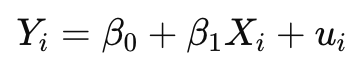

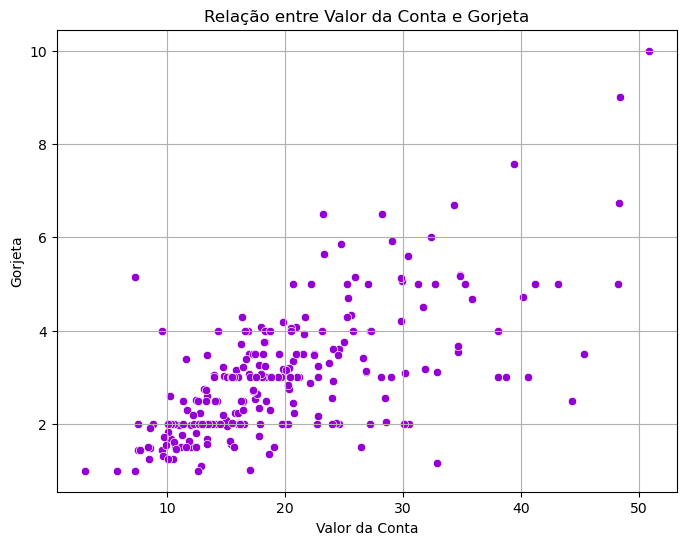

In [ ]:
# Definindo as variáveis independentes (X) e dependente (Y)
X = df['total_bill']
y = df['tip']

# Plotando o gráfico de dispersão
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=df, color = 'darkviolet')
plt.title('Relação entre Valor da Conta e Gorjeta')
plt.xlabel('Valor da Conta')
plt.ylabel('Gorjeta')
plt.grid(True)
plt.show()

Para uma melhor explicação, citaremos um exemplo para relembrar o que é população e amostra. População: Todos os alunos da FGV ; Amostra: 200 alunos selecionados, que estudam na FGV.

Note que esse modelo traz os valores populacionais (todos os valores possíveis da população em questão), e lembrando da aula de estatística, é muito custoso ou mesmo impossível ter todos esses valores. Na prática, o que fazemos é estimar a reta que melhor explica essa relação com os dados que nós temos (MQO - Mínimos Quadrados Ordinários, que é um método de estimar o modelo de Regressão Linear).

A distância que temos da observação de cada ponto à linha estimada é chamada de resíduo (o quanto o modelo errou na previsão daquela observação). A conta que fazemos é a minimização do somatórios dos resíduos quadráticos. Para quem está acostumado com cálculo, derivaremos e igualaremos a 0, para os dois argumentos, a seguinte expressão:

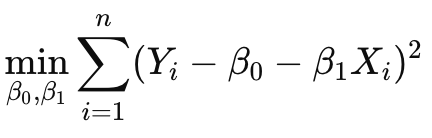

Em Python o que teremos é:

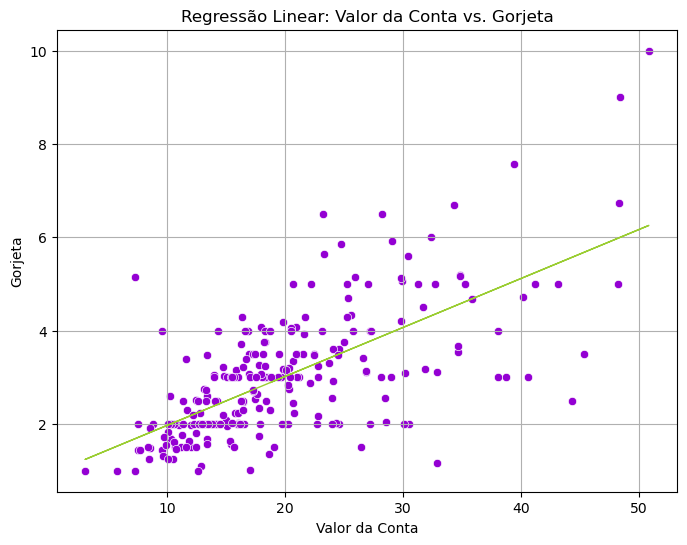

const         0.920270
total_bill    0.105025
dtype: float64


In [ ]:
# Criando o modelo de regressão linear
X = sm.add_constant(X)
#Estima a regressão
model = sm.OLS(y, X).fit()

# Plotando o gráfico da regressão linear
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', data=df, color = 'darkviolet')
plt.plot(df['total_bill'], model.predict(X), color = 'yellowgreen', linewidth=1)
plt.title('Regressão Linear: Valor da Conta vs. Gorjeta')
plt.xlabel('Valor da Conta')
plt.ylabel('Gorjeta')
plt.grid(True)
plt.show()

print(model.params)

Dessa forma, o modelo que temos é:

tip = 0.920270 + 0.105025*total_bill

## 1.4 - Medidas de ajuste

Nem sempre uma regressão linear consegue explicar bem os dados. Por isso, podemos usar algumas medidas de ajuste para ver se o modelo está funcionando bem.

A principal delas é o R²:

O **R²** mostra quanto da variação da variável que queremos explicar (Y) pode ser explicada pela variável que estamos usando para explicá-la (X).

Ele representa a proporção da variação amostral da variável dependente explicada pela variação amostral da variável independente.

Sua fórmula pode ajudar melhor a entender essa ideia:

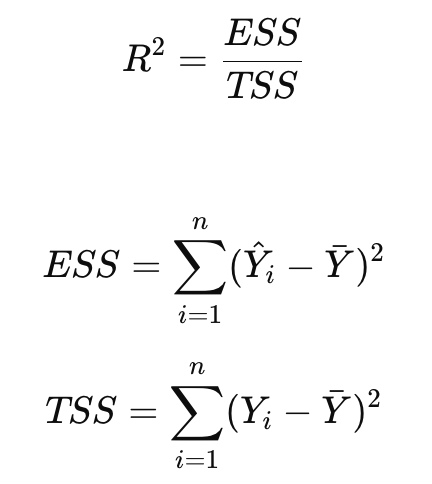

Podemos verificar se nossa regressão se adequa da seguinte forma:

In [ ]:
print(f"R^2: {model.rsquared}")

R^2: 0.45661658635167646


## 1.5 - Hipóteses necessárias

Note que nem toda essa variação é explicada pelas variáveis da nossa regressão.

Antes de tentar melhorar o modelo, precisamos verificar se algumas condições básicas estão sendo cumpridas para que a regressão faça sentido.

**Linearidade**: A relação entre X e Y deve ser linear. Isso pode ser verificado visualmente por meio de um gráfico de dispersão.


**Independência das observações**: Os erros (resíduos) do modelo de regressão devem ser independentes uns dos outros. Isso significa que os valores em uma observação não devem depender dos valores em outra observação. Se esta hipótese for violada e houver relação entre as observações, cometeremos erros em praticamente todos os testes de hipótese, passos e características da nossa regressão.


**Independência de X e dos Erros**: A variável independente X e os erros devem ser independentes entre si. Isso significa que não deve haver relação sistemática entre X e os erros do modelo.
A violação dessa suposição pode levar a vieses nos coeficientes estimados e afetar a validade dos testes estatísticos realizados na análise de regressão. Os coeficientes podem estar enviesados, e os intervalos de confiança e testes de hipóteses podem não ser confiáveis. Isso pode levar a conclusões errôneas sobre a significância das variáveis independentes.


**Homoscedasticidade (ou ausência de heterocedasticidade)**: A variância dos erros deve ser constante em todos os níveis de X. Em outras palavras, a dispersão dos erros deve ser a mesma para todos os valores de X. Isso pode ser verificado visualmente por meio de um gráfico de resíduos em relação a X, mas formalmente, devemos realizar um teste de hipótese para verificar se há ou não homocedasticidade. Isso pois, caso haja heterocedasticidade, perdemos tanto a característica de eficiência (menor variação na estimação dos coeficientes) e podemos ter testes de hipóteses viesados, subestimando ou superestimando a significância estatística.

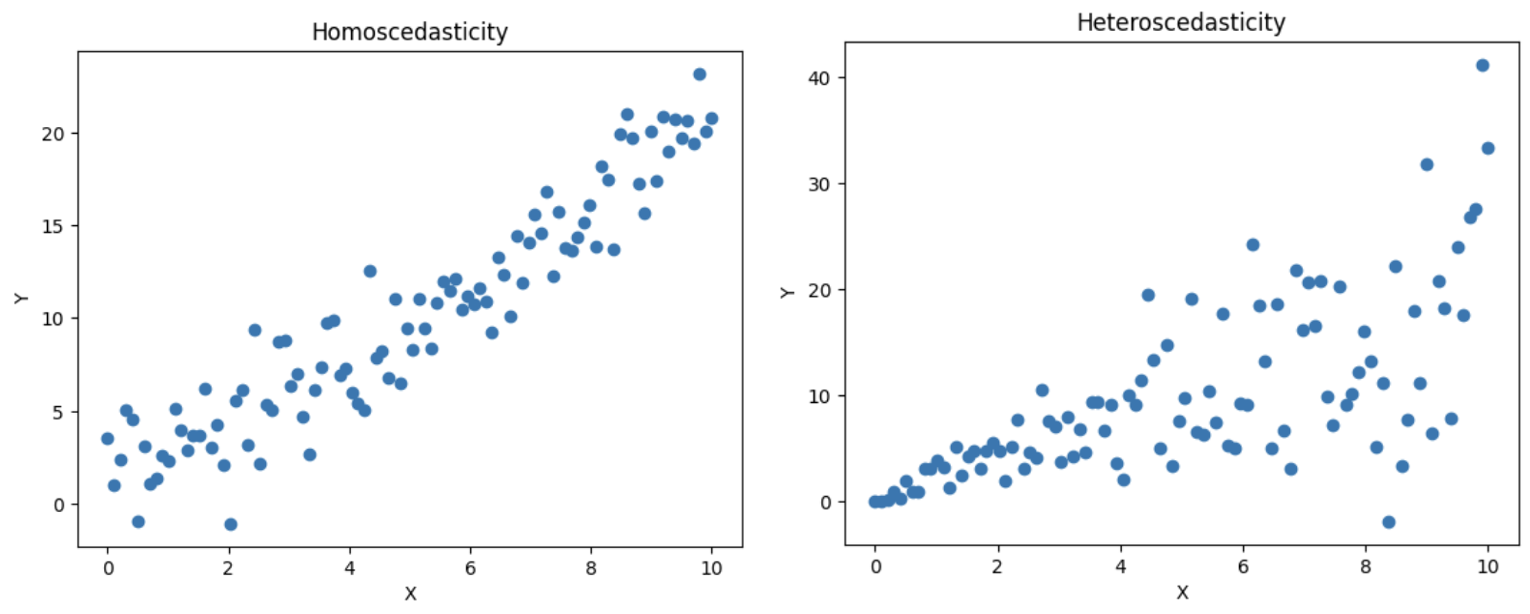

Para verificar se existe heterocedasticidade, podemos usar testes como o Breusch-Pagan e o teste de White.

Se encontrarmos heterocedasticidade, podemos tentar corrigir o problema de algumas formas:

-Transformar os dados, por exemplo usando log ou raiz;

-Usar métodos robustos, que permitem fazer os testes estatísticos mesmo quando existe heterocedasticidade.

## 2 - Regressão múltipla

A regressão linear simples usa uma variável X para tentar explicar Y. Mas, às vezes, uma única variável não é suficiente.

Por isso, usamos a regressão múltipla, que permite usar duas ou mais variáveis X ao mesmo tempo para explicar Y.

Por exemplo, em vez de tentar explicar o salário de uma pessoa apenas pela educação, podemos considerar também experiência, idade e horas trabalhadas.

Assim, conseguimos analisar como cada variável está relacionada com Y enquanto consideramos as outras variáveis do modelo.

## Viés de variável omitida

Suponha que existe um modelo perfeito, que o econometrista nunca vai conseguir formular pelos diversos motivos citados anteriormente. Seja ele:

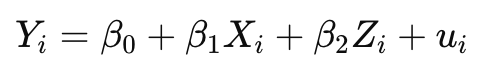

O que acontece se fizermos uma estimação de Y, por OLS, pensando que, na verdade o modelo correto é o anterior, do caso univariado? Isto é, se estimarmos:

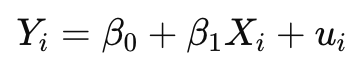


Viés de variável omitida acontece quando deixamos de fora do modelo uma variável que também influencia Y.

Nesse caso, o modelo pode acabar atribuindo a outra variável um efeito que, na verdade, pertence parcialmente à variável que foi esquecida.

Por isso, os resultados da regressão podem ficar errados, fazendo com que o efeito de uma variável seja maior ou menor do que realmente é.

Exemplo:

Queremos descobrir se educação (X) influencia salário (Y):
$$ Salário = \beta_0 + \beta_1 Educação + u $$
Mas o número de anos de experiência também influencia o salário e foi deixado de fora.
Então, parte do efeito da experiência pode acabar sendo atribuída à educação.

## 2.1 - Estimação

Caso você esteja idealizando o modelo correto, o procedimento para a estimação dos coeficientes é semelhante ao do caso univariado, isto é, você deve derivar e minizar a equação:

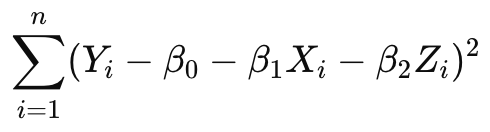

Ou podemos ter o caso generalizado, para k variáveis, como segue:

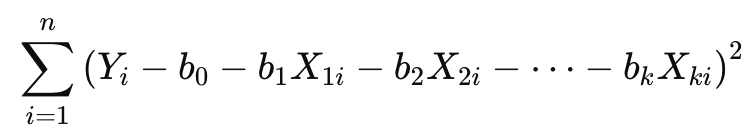

Quando estamos lidando em casos mais complexos, teremos que lidar com essas contas em matrizes, e é preciso certo conhecimento de álgebra linear e cálculo para fazer essas derivações matemáticas. O intuito dessa aula não é entrar nessas questões mais técnicas, mas estarei aberto caso queiram aprender alguma dessas derivações.

## 2.2 - Medidas de ajuste

Dado que agora nosso modelo explica melhor os dados, devemos voltar à ideia das **medidas de ajuste**. Fazendo os ajustes necessários para comportar as novas variáveis, ainda temos:

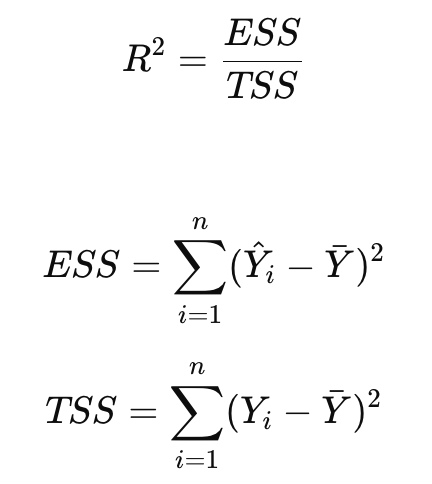

Intuitivamente, podemos imaginar que o R^2 vai ser mais alto que o do caso univariado. Na verdade, isso acontece sempre, por consequências matemáticas. Dessa forma, o R^2 pode não ser uma boa medida de ajuste, dado que podemos estar inflando seus valores, o que afeta nossa interpretação.

A solução é o **R^2 ajustado**, em que estaremos "punindo" o R^2 para cada novo regressor adicionado. Sua expressão é:

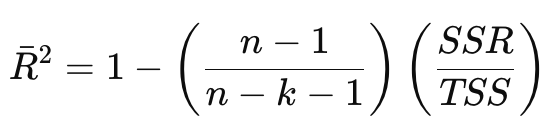

em que

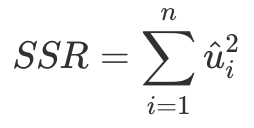

## 2.3 - Variáveis binárias

Se você prestar atenção, poderá notar que na base de dados da regressão que fizemos, algumas das variáveis que temos não são numéricas, o que é o caso de "sex", "smoker", "day" e "time". Ignoremos as duas últimas duas, por enquanto, e foques nas duas primeiras. Note que "sex" e "smoker", nessa base de dados, podem assumir dois valores. Chamamos tal tipo de variável de "variável dummy", e também podemos incluí-las nas regressões.

Voltemos ao caso da regressão univariada, em que tentaremos modelar o total de gorjeta para uma variável que assume apenas dois valores.



In [ ]:
# Carrega o dataset
df = sns.load_dataset('tips')
# Transforma sex em uma variável dummy
df = pd.get_dummies(df, columns=["sex"], drop_first=True)
df = df.rename(columns={'sex_Female': 'female'})

,total_bill,tip,smoker,day,time,size,female
0,16.99,1.01,No,Sun,Dinner,2,1
1,10.34,1.66,No,Sun,Dinner,3,0
2,21.01,3.50,No,Sun,Dinner,3,0
3,23.68,3.31,No,Sun,Dinner,2,0
4,24.59,3.61,No,Sun,Dinner,4,1
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,0
240,27.18,2.00,Yes,Sat,Dinner,2,1
241,22.67,2.00,Yes,Sat,Dinner,2,0
242,17.82,1.75,No,Sat,Dinner,2,0


Regressão linear simples para ver a relação entre sexo e valor da gorjeta:

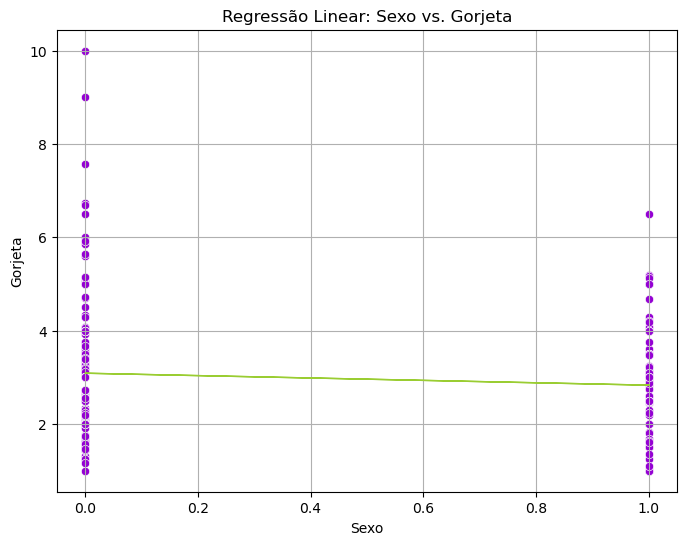

const     3.089618
female   -0.256170
dtype: float64


In [ ]:
# Define X e Y
X = df['female']
y = df['tip']
# Adiciona a constante
X = sm.add_constant(X)
# Faz a regressão usando OLS
model = sm.OLS(y, X).fit()

# Plotando o gráfico da regressão linear
plt.figure(figsize=(8, 6))
sns.scatterplot(x='female', y='tip', data=df, color = 'darkviolet')
plt.plot(df['female'], model.predict(X), color = 'yellowgreen', linewidth=1)
plt.title('Regressão Linear: Sexo vs. Gorjeta')
plt.xlabel('Sexo')
plt.ylabel('Gorjeta')
plt.grid(True)
plt.show()

print(model.params)
